In [1]:
!pip install -q torch torchvision albumentations tqdm scikit-learn seaborn

In [2]:
from pathlib import Path
import torch

CFG = {
    'data_dir'   : Path('dataset'),
    'img_size'   : 128,
    'batch_size' : 32,
    'epochs'     : 30,
    'lr'         : 1e-3,
    'patience'   : 7,
    'ckpt'       : Path('checkpoints/best.pth'),
    'num_workers': 2,
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
CFG['ckpt'].parent.mkdir(exist_ok=True)

cuda


In [ ]:
CLASSES = ['chihuahua', 'muffin']
for split in ['train', 'test']:
    for cls in CLASSES:
        p = CFG['data_dir'] / split / cls
        n = len(list(p.glob('*'))) if p.exists() else 0
        print(f'{split}/{cls} : {n}')

train/chihuahua : 2559
train/muffin : 2174
test/chihuahua : 640
test/muffin : 544


In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader

MEAN = np.array([0.5, 0.5, 0.5])
STD  = np.array([0.5, 0.5, 0.5])

train_tf = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

class DogMuffinDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        for label, cls in enumerate(CLASSES):
            for p in (root / cls).glob('*'):
                if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
                    self.samples.append((p, label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        return img, label

train_ds = DogMuffinDataset(CFG['data_dir'] / 'train', train_tf)
val_ds   = DogMuffinDataset(CFG['data_dir'] / 'test',  val_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f'train : {len(train_ds)} | val : {len(val_ds)}')

train : 4733 | val : 1184


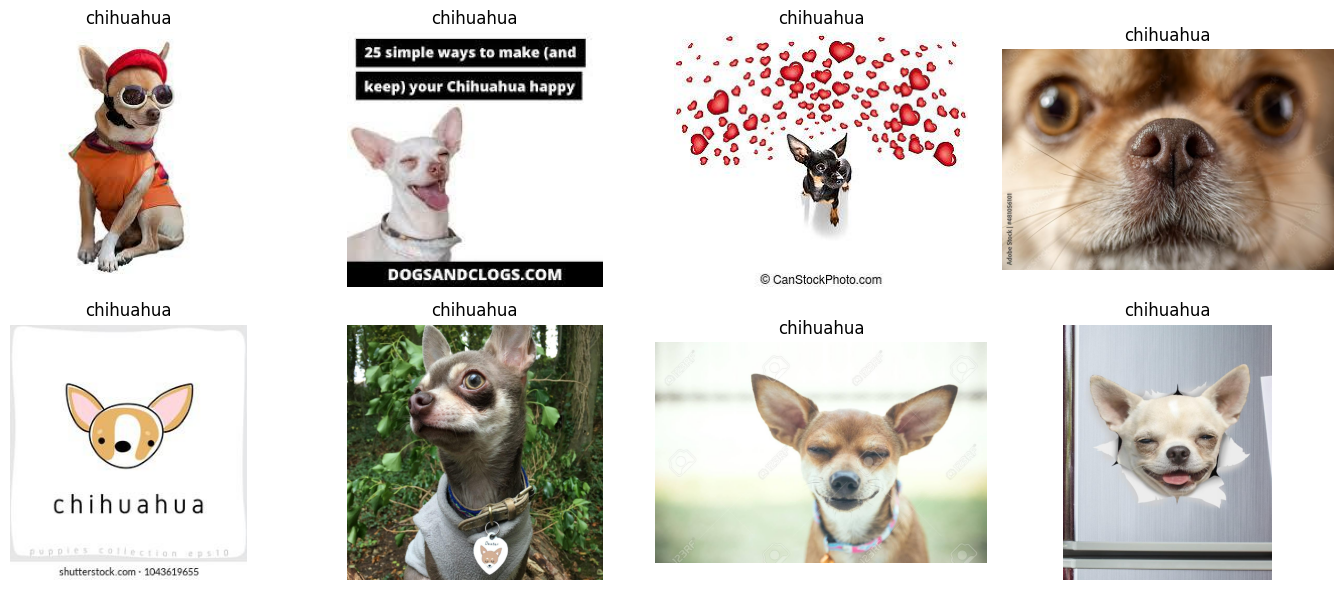

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, (path, label) in enumerate(train_ds.samples[:8]):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    axes[i//4][i%4].imshow(img)
    axes[i//4][i%4].set_title(CLASSES[label])
    axes[i//4][i%4].axis('off')
plt.tight_layout()
plt.show()

In [6]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # bloc 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            # bloc 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # bloc 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # bloc 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN().to(device)
print(f'params : {sum(p.numel() for p in model.parameters())/1e6:.2f}M')

params : 0.41M


In [7]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

loss_fn   = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=CFG['lr'])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

best_acc   = 0.0
no_improve = 0
history    = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, CFG['epochs'] + 1):
    model.train(); train_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f'ep {epoch:02d} train'):
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval(); val_loss = 0; correct = 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'ep {epoch:02d} val  '):
            imgs   = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            logits = model(imgs)
            val_loss += loss_fn(logits, labels).item()
            preds    = (torch.sigmoid(logits) > 0.5).float()
            correct  += (preds == labels).sum().item()
    val_loss /= len(val_loader)
    val_acc   = correct / len(val_ds)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'ep {epoch:02d} | train={train_loss:.4f} | val={val_loss:.4f} | acc={val_acc:.4f}')

    if val_acc > best_acc:
        best_acc = val_acc; no_improve = 0
        torch.save({'epoch': epoch, 'val_acc': val_acc,
                    'state_dict': model.state_dict()}, CFG['ckpt'])
        print(f'  best acc={best_acc:.4f}')
    else:
        no_improve += 1
        if no_improve >= CFG['patience']:
            print(f'early stopping ep {epoch}'); break

print(f'best val acc : {best_acc:.4f}')

ep 01 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 12.97it/s]


ep 01 | train=0.4167 | val=0.5860 | acc=0.7458
  best acc=0.7458


ep 02 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 12.84it/s]


ep 02 | train=0.3206 | val=0.2761 | acc=0.8843
  best acc=0.8843


ep 03 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 13.43it/s]


...

ep 28 | train=0.1036 | val=0.1233 | acc=0.9561


ep 29 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 15.59it/s]


ep 29 | train=0.0977 | val=0.1206 | acc=0.9561


ep 30 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:03<00:00, 12.03it/s]

ep 30 | train=0.0955 | val=0.1205 | acc=0.9578
best val acc : 0.9578


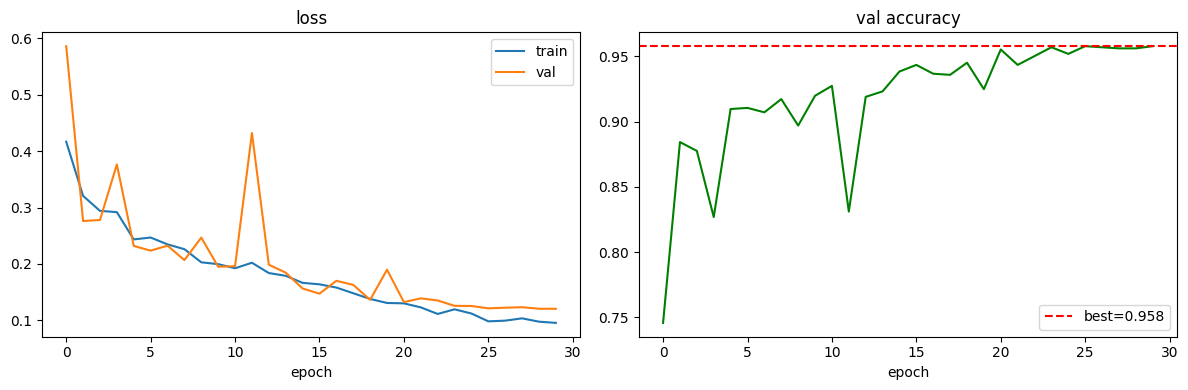

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'],   label='val')
ax1.set_title('loss'); ax1.legend(); ax1.set_xlabel('epoch')
ax2.plot(history['val_acc'], color='green')
ax2.axhline(best_acc, color='red', linestyle='--', label=f'best={best_acc:.3f}')
ax2.set_title('val accuracy'); ax2.legend(); ax2.set_xlabel('epoch')
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

   chihuahua       0.95      0.97      0.96       640
      muffin       0.96      0.94      0.95       544

    accuracy                           0.96      1184
   macro avg       0.96      0.96      0.96      1184
weighted avg       0.96      0.96      0.96      1184



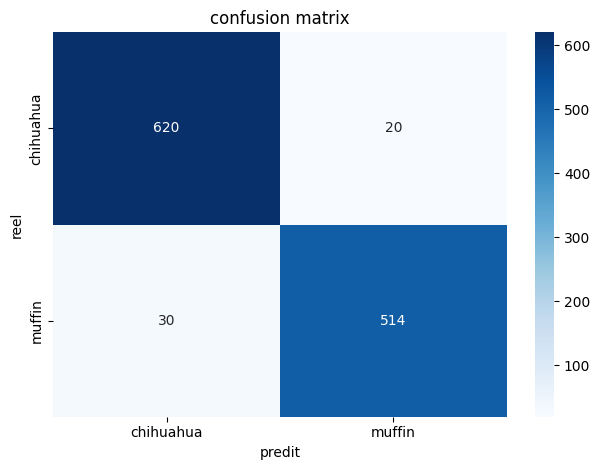

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

ckpt = torch.load(CFG['ckpt'], map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = (torch.sigmoid(model(imgs.to(device))) > 0.5).long().cpu().squeeze(1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('confusion matrix')
plt.ylabel('reel'); plt.xlabel('predit')
plt.tight_layout(); plt.show()

chihuahua (100.0%)


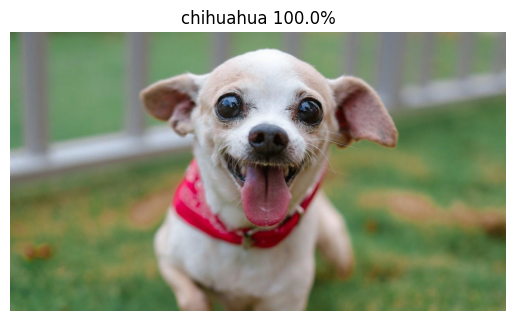

chihuahua (99.5%)


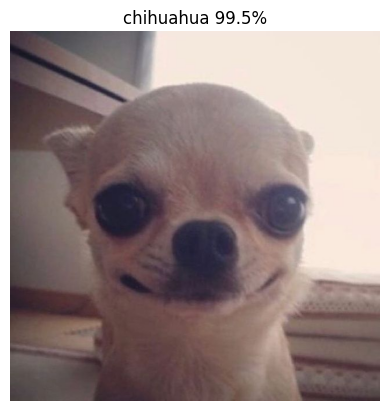

chihuahua (99.4%)


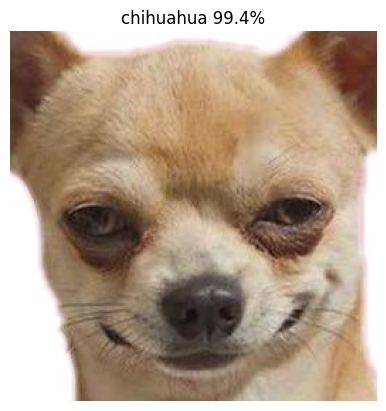

chihuahua (95.8%)


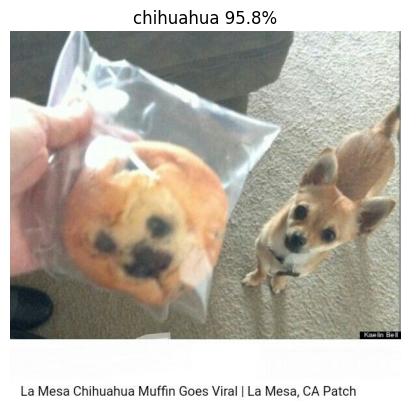

In [14]:
def predict(img_path):
    img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    t    = val_tf(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(t)).item()
    label = CLASSES[int(prob > 0.5)]
    conf  = prob if prob > 0.5 else 1 - prob
    print(f'{label} ({conf*100:.1f}%)')
    plt.imshow(img); plt.title(f'{label} {conf*100:.1f}%'); plt.axis('off'); plt.show()

predict('test2.jpg')
predict('test3.jpg')
predict('test4.jpg')
predict('test5.jpg')